In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
    confusion_matrix,classification_report,roc_curve)

In [2]:
train = pd.read_csv("../data/processed/train_smote.csv")
test = pd.read_csv("../data/processed/test_data.csv")
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (1582354, 48)
Test Shape : (200000, 48)


In [3]:
X_train = train.drop("fraud_bool", axis=1)
y_train = train["fraud_bool"]
X_test = test.drop("fraud_bool", axis=1)
y_test = test["fraud_bool"]

In [4]:
rf = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=10,min_samples_leaf=5,
random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [5]:
#prediction 
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [6]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.966515


In [7]:
#Precision, Recall & F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Precision : 0.10249601699415826
Recall : 0.26246600181323665
F1 Score : 0.14742202418841502


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98    197794
           1       0.10      0.26      0.15      2206

    accuracy                           0.97    200000
   macro avg       0.55      0.62      0.57    200000
weighted avg       0.98      0.97      0.97    200000



In [9]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[192724   5070]
 [  1627    579]]


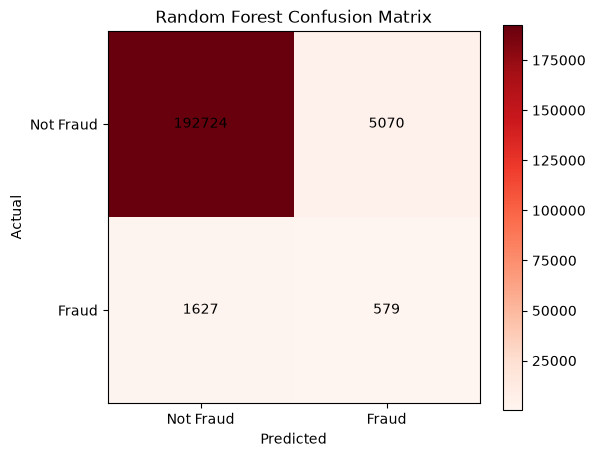

In [10]:
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Reds")
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
plt.xticks([0,1],["Not Fraud","Fraud"])
plt.yticks([0,1],["Not Fraud","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")
plt.show()

In [11]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC :", auc)

ROC-AUC : 0.8460103335071423


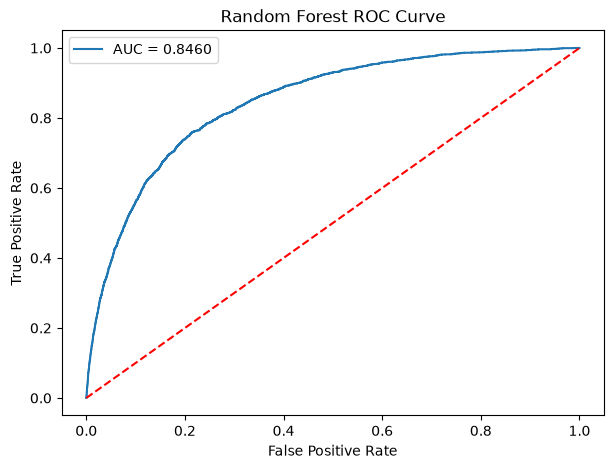

In [12]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

In [13]:
#Feature Importance
importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(20)

,Feature,Importance
22,keep_alive_session,0.101604
37,housing_status_2,0.098408
15,phone_home_valid,0.093237
4,customer_age,0.091453
36,housing_status_1,0.083555
44,device_os_2,0.075429
18,has_other_cards,0.059947
39,housing_status_4,0.058661
3,current_address_months_count,0.052368
17,bank_months_count,0.038829


In [14]:
importance.to_csv("../data/processed/random_forest_feature_importance.csv",index=False)
print("Feature importance saved.")

Feature importance saved.


In [15]:
joblib.dump(rf,"../models/random_forest.pkl")
print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [16]:
print("Random Forest Summary")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Random Forest Summary
Accuracy  : 0.9665
Precision : 0.1025
Recall    : 0.2625
F1 Score  : 0.1474
ROC-AUC   : 0.8460


## Summary

• Loaded the feature-engineered fraud detection dataset.
• Split the dataset into training and testing sets.
• Trained a Random Forest Classifier.
• Generated predictions on the test data.
• Evaluated model performance using Accuracy, Precision, Recall, F1-score, Confusion Matrix,  Classification Report, and ROC-AUC score.
• Visualized the ROC curve.
• Analyzed feature coefficients to understand feature importance.
• Saved the trained Logistic Regression model for future use.